<a href="https://colab.research.google.com/github/tobiasllop/Tesis/blob/main/Parte_B_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Parte B - Tesis Tobias Llop

---
**Disclaimer:** siguiente notebook utiliza muchas tecnicas de chunking y almacenamiento intermedo de dataframes para optimizar la Memoria RAM del entorno gratuito de colab.


In [3]:
!pip install prince
!pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.3/197.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 34.7 MB/s eta 0:00:00


# Data Loading Deudas Enero 2026

In [4]:
import pandas as pd
import gc
import fastparquet

# 1. Cargar catálogo
ruta_entidades = '/content/drive/MyDrive/Tesis2026/EntidadesFinancierasBCRA.csv'
entidades = pd.read_csv(ruta_entidades)[['cod_entidad', 'grupo_entidad']]
entidades['cod_entidad'] = entidades['cod_entidad'].astype(str).str.zfill(5)

# 2. Cargar y procesar deudores
ruta_deudores_26 = '/content/drive/MyDrive/Tesis2026/deudores_final_enero.parquet'
chunks_list = []

try:
    parquet_file = fastparquet.ParquetFile(ruta_deudores_26)
    for i, chunk in enumerate(parquet_file.iter_row_groups(columns=['cod_entidad', 'tipo_id', 'nro_id', 'prestamos'])):
        chunk = chunk[chunk['tipo_id'] == '11'].copy()
        if not chunk.empty:
            chunk = chunk.rename(columns={'nro_id': 'cuit', 'prestamos': 'deuda_total'})
            chunk['cuit'] = chunk['cuit'].astype(str)
            chunk['cod_entidad'] = chunk['cod_entidad'].astype(str).str.zfill(5)
            chunk = pd.merge(chunk, entidades, on='cod_entidad', how='left')
            chunks_list.append(chunk[['cuit', 'deuda_total', 'grupo_entidad']])
        if i % 100 == 0: gc.collect()

    df_2026 = pd.concat(chunks_list, ignore_index=True)

    # Clasificar y obtener cortes
    df_2026['Tamanio_Deuda'], bins = pd.qcut(df_2026['deuda_total'], q=4, labels=['Muy Pequeña', 'Pequeña', 'Mediana', 'Grande'], retbins=True)
    print(f"Cortes de Deuda: {bins}")

    # Guardar archivo intermedio y limpiar
    ruta_intermedia_deuda = '/content/drive/MyDrive/Tesis2026/deudas_enero_2026_Categoricas.parquet'
    df_2026[['cuit', 'grupo_entidad', 'Tamanio_Deuda']].to_parquet(ruta_intermedia_deuda, index=False)
    print(f"Archivo de deudas guardado en: {ruta_intermedia_deuda}")

    del df_2026, chunks_list
    gc.collect()
except Exception as e:
    print(f"Error: {e}")

Cortes de Deuda: [0.00000000e+00 1.50000000e+02 5.39000000e+02 1.63700000e+03
 6.96279749e+08]
Archivo de deudas guardado en: /content/drive/MyDrive/Tesis2026/deudas_enero_2026_Categoricas.parquet


# Data Loading - Padron Fisicas Enero 2026

In [ ]:
import pandas as pd
import numpy as np
import gc
import fastparquet

ruta_padron = '/content/drive/MyDrive/Tesis2026/padron_fisicas_enero.parquet'
chunks_finales = []

try:
    pf = fastparquet.ParquetFile(ruta_padron)
    cols = ['cuit', 'sexo', 'fecha_nacimiento', 'provincia', 'codigo_postal', 'fecha_fallecimiento']

    for i, chunk in enumerate(pf.iter_row_groups(columns=cols)):
        # Limpieza: se excluye explícitamente el género 'X'
        chunk['fecha_nacimiento'] = pd.to_datetime(chunk['fecha_nacimiento'], errors='coerce')
        mask = (chunk['fecha_fallecimiento'] == '') & (chunk['sexo'] != '') & (chunk['sexo'] != 'X')
        chunk = chunk[mask].copy()
        if chunk.empty: continue

        # Ingeniería de atributos
        chunk['Rango_Etario'] = pd.cut(2026 - chunk['fecha_nacimiento'].dt.year, bins=[17, 25, 40, 65, 120], labels=['Jóvenes', 'Adultos_Ins', 'Adultos_Cons', 'Adultos_May'])

        prov = pd.to_numeric(chunk['provincia'], errors='coerce').fillna(-1)
        cp = pd.to_numeric(chunk['codigo_postal'], errors='coerce').fillna(-1)

        condiciones = [
            (prov == 0),
            (prov == 1) & (cp.between(1600, 1900))
        ]
        opciones = ['CABA', 'AMBA']
        chunk['Region'] = np.select(condiciones, opciones, default='Interior')

        chunk = chunk[['cuit', 'sexo', 'Rango_Etario', 'Region']].rename(columns={'sexo': 'Genero'})
        chunk['cuit'] = chunk['cuit'].astype(str)
        chunks_finales.append(chunk)

        if i % 100 == 0:
            gc.collect()

    df_padron_procesado = pd.concat(chunks_finales, ignore_index=True)

    ruta_intermedia_padron = '/content/drive/MyDrive/Tesis2026/padron_categorico_enero_2026.parquet'
    df_padron_procesado.to_parquet(ruta_intermedia_padron, index=False)
    print(f"Archivo de padrón (sin Género X) guardado en: {ruta_intermedia_padron}")

    del df_padron_procesado, chunks_finales
    gc.collect()
except Exception as e:
    print(f"Error: {e}")

Archivo de padrón (sin Género X) guardado en: /content/drive/MyDrive/Tesis2026/padron_categorico_enero_2026.parquet


# Celda 2: Merge

In [5]:
!pip install polars
import polars as pl
import pandas as pd
import gc
import os

ruta_deuda = '/content/drive/MyDrive/Tesis2026/deudas_enero_2026_Categoricas.parquet'
ruta_padron = '/content/drive/MyDrive/Tesis2026/padron_categorico_enero_2026.parquet'
ruta_mca_final = '/content/drive/MyDrive/Tesis2026/df_mca_2026_final.parquet'

# Borrar si ya existe para empezar limpio
if os.path.exists(ruta_mca_final): os.remove(ruta_mca_final)

print("Iniciando Join ultra-eficiente con Polars (Lazy Engine)...")

# Escaneamos los archivos
d_lazy = pl.scan_parquet(ruta_deuda)
p_lazy = pl.scan_parquet(ruta_padron)

for digito in range(10):
    print(f"Procesando fragmento CUIT termina en {digito}...      ", end='\r')

    filtro = pl.col('cuit').str.ends_with(str(digito))

    fragmento_join = (
        d_lazy.filter(filtro)
        .join(p_lazy.filter(filtro), on='cuit', how='inner')
        .drop('cuit')
        .drop_nulls()
        .collect()
    )

    if fragmento_join.height > 0:
        df_temp = fragmento_join.to_pandas()
        for col in df_temp.columns:
            df_temp[col] = df_temp[col].astype('category')

        if not os.path.exists(ruta_mca_final):
            df_temp.to_parquet(ruta_mca_final, engine='fastparquet', index=False)
        else:
            df_temp.to_parquet(ruta_mca_final, engine='fastparquet', append=True, index=False)

        del df_temp

    del fragmento_join
    gc.collect()

# Liberar punteros lazy antes de la carga final
del d_lazy, p_lazy
gc.collect()

print("\n¡Proceso finalizado con Polars! Cargando resultado final...")
df_mca_2026 = pd.read_parquet(ruta_mca_final)
print(f"Registros totales consolidados: {len(df_mca_2026)}")
display(df_mca_2026.info())
display(df_mca_2026.head())

Iniciando Join ultra-eficiente con Polars (Lazy Engine)...

¡Proceso finalizado con Polars! Cargando resultado final...
Registros totales consolidados: 39017247
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39017247 entries, 0 to 39017246
Data columns (total 5 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   grupo_entidad  object
 1   Tamanio_Deuda  object
 2   Genero         object
 3   Rango_Etario   object
 4   Region         object
dtypes: object(5)
memory usage: 1.5+ GB


None

,grupo_entidad,Tamanio_Deuda,Genero,Rango_Etario,Region
0,Entidad Financiera,Mediana,F,Adultos_Cons,Interior
1,Otras PNFC,Muy Pequeña,F,Adultos_Cons,Interior
2,Entidad Financiera,Mediana,M,Adultos_May,Interior
3,Entidad Financiera,Muy Pequeña,F,Adultos_Ins,AMBA
4,Entidad Financiera,Grande,M,Adultos_Cons,AMBA


# Celda 3: Análisis Estadístico y Gráficos

Calculando frecuencias para los gráficos...


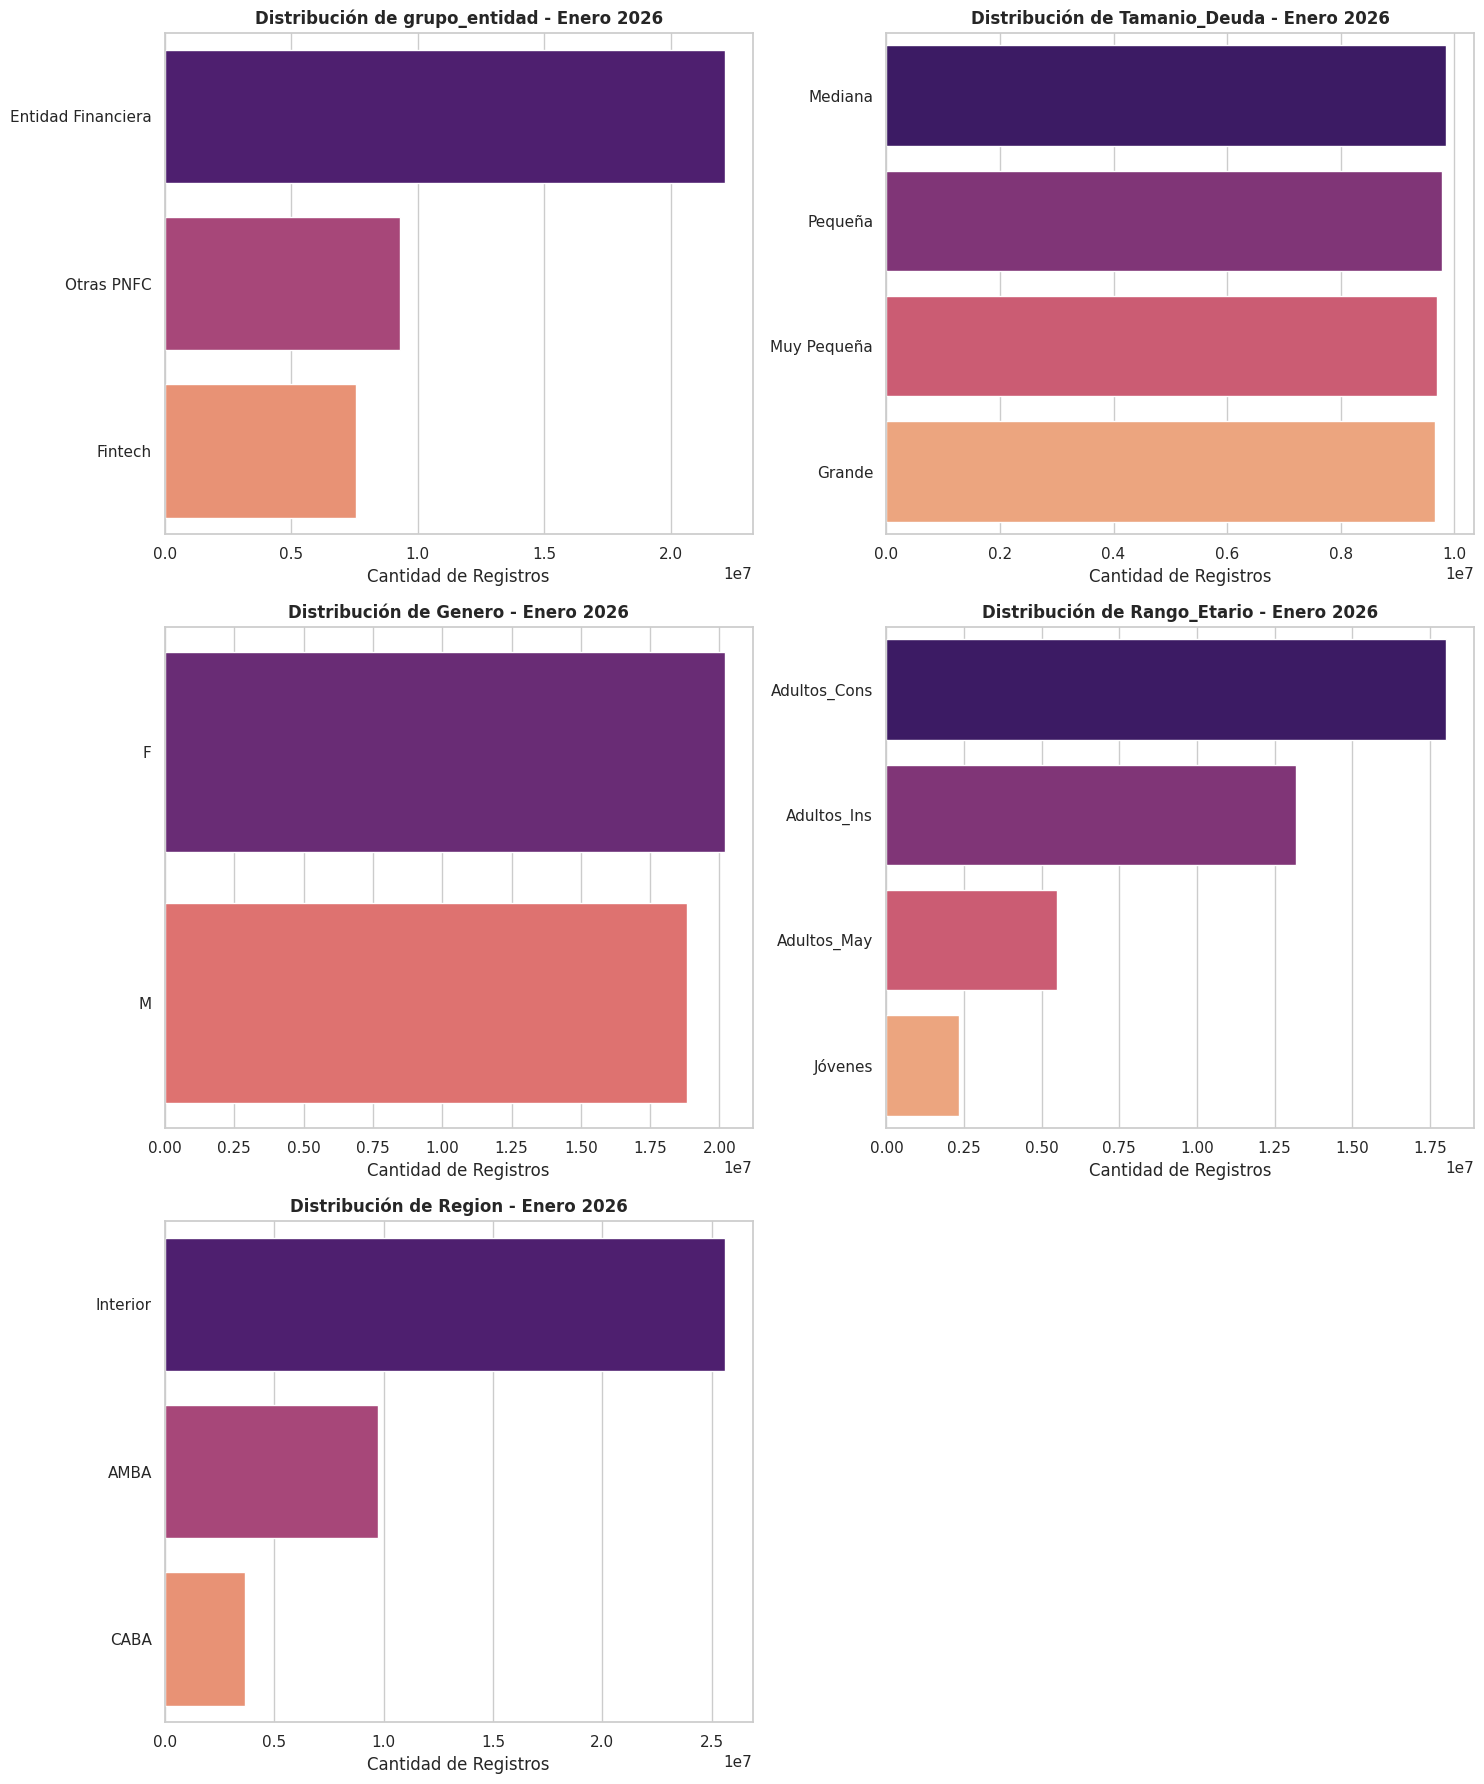

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

ruta_mca_final = '/content/drive/MyDrive/Tesis2026/df_mca_2026_final.parquet'

# Verificar y cargar el dataset si no está en memoria
if 'df_mca_2026' not in locals():
    if os.path.exists(ruta_mca_final):
        print("Cargando dataset consolidado desde Drive...")
        df_mca_2026 = pd.read_parquet(ruta_mca_final)
    else:
        print("Error: No se encontró el archivo consolidado en Drive. Por favor ejecuta la celda de Merge (Jr3KARMBXJEX) primero.")

if 'df_mca_2026' in locals():
    # Definir columnas para el análisis
    cols_categoricas = ['grupo_entidad', 'Tamanio_Deuda', 'Genero', 'Rango_Etario', 'Region']

    # Configuración de estilo
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    axes = axes.flatten()

    print("Calculando frecuencias para los gráficos...")

    for i, col in enumerate(cols_categoricas):
        # OPTIMIZACIÓN: Calculamos frecuencias para no saturar RAM graficando filas crudas
        counts = df_mca_2026[col].value_counts().reset_index()
        counts.columns = [col, 'count']

        sns.barplot(y=col, x='count', data=counts,
                    ax=axes[i], palette='magma', hue=col, legend=False)

        axes[i].set_title(f'Distribución de {col} - Enero 2026', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Cantidad de Registros')
        axes[i].set_ylabel('')

    if len(axes) > len(cols_categoricas):
        fig.delaxes(axes[5])

    plt.tight_layout()
    plt.show()

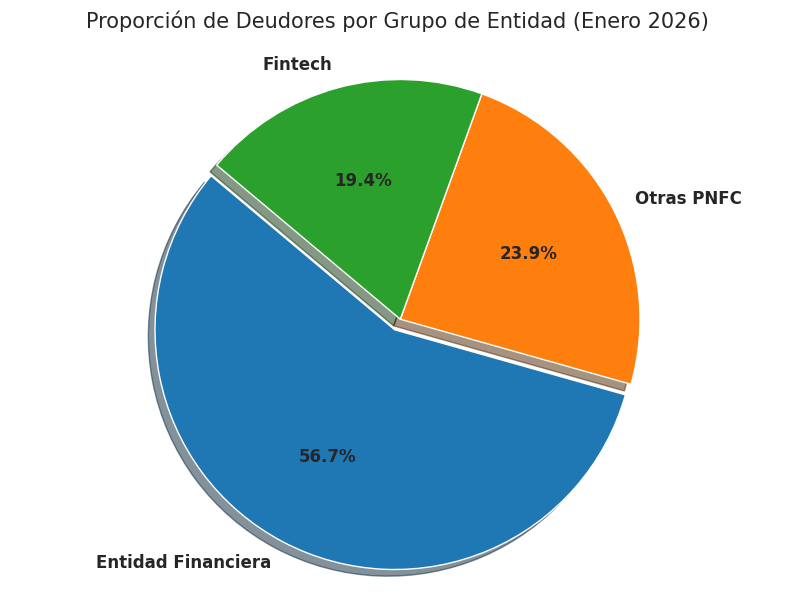

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Verificar que el dataframe esté disponible
if 'df_mca_2026' in locals():
    # Calcular frecuencias
    proporcion = df_mca_2026['grupo_entidad'].value_counts()

    # Configuración del gráfico
    plt.figure(figsize=(10, 7))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Colores consistentes con el MCA

    plt.pie(proporcion,
            labels=proporcion.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=colors,
            explode=(0.05, 0, 0),
            shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})

    plt.title('Proporción de Deudores por Grupo de Entidad (Enero 2026)', fontsize=15, pad=20)
    plt.axis('equal')  # Asegura que sea un círculo
    plt.show()
else:
    print("Error: El dataset 'df_mca_2026' no está cargado en memoria.")

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import fastparquet

# 1. Cargamos el catálogo con detección robusta de columnas
ruta_entidades = '/content/drive/MyDrive/Tesis2026/EntidadesFinancierasBCRA.csv'
entidades_raw = pd.read_csv(ruta_entidades)

# Buscamos columnas por palabras clave para evitar errores de tildes o nombres distintos
def find_col(keywords, df):
    for k in keywords:
        found = [c for c in df.columns if k in c.lower()]
        if found: return found[0]
    return None

col_nombre = find_col(['nombre', 'denom'], entidades_raw)
col_cod = find_col(['cod', 'id_ent'], entidades_raw)
col_grupo = find_col(['grupo'], entidades_raw)

if not all([col_nombre, col_cod, col_grupo]):
    print(f"Columnas detectadas: Nombre={col_nombre}, Cod={col_cod}, Grupo={col_grupo}")
    raise ValueError("No se pudieron identificar todas las columnas necesarias en el CSV.")

entidades_full = entidades_raw[[col_cod, col_nombre, col_grupo]].copy()
entidades_full.columns = ['cod_entidad', 'denominacion', 'grupo_entidad']
entidades_full['cod_entidad'] = entidades_full['cod_entidad'].astype(str).str.zfill(5)

print("--- Análisis de Entidades Específicas ---")

# 2. Procesamos el archivo de deudores original para obtener porcentajes reales
ruta_deudores_26 = '/content/drive/MyDrive/Tesis2026/deudores_final_enero.parquet'

try:
    pf = fastparquet.ParquetFile(ruta_deudores_26)
    conteo_entidades = pd.Series(dtype='int64')

    print("Contabilizando registros por entidad (esto puede demorar un momento)...")
    for chunk in pf.iter_row_groups(columns=['cod_entidad']):
        counts = chunk['cod_entidad'].astype(str).str.zfill(5).value_counts()
        conteo_entidades = conteo_entidades.add(counts, fill_value=0)

    resumen = pd.DataFrame(conteo_entidades).reset_index()
    resumen.columns = ['cod_entidad', 'cantidad']
    resumen = pd.merge(resumen, entidades_full, on='cod_entidad', how='left')

    total_total = resumen['cantidad'].sum()
    resumen['porcentaje'] = (resumen['cantidad'] / total_total) * 100

    # Filtramos por Tarjeta Naranja
    naranja = resumen[resumen['denominacion'].str.contains('NARANJA', case=False, na=False)]

    if not naranja.empty:
        print("\nResultado para la consulta:")
        for _, row in naranja.iterrows():
            print(f"* {row['denominacion']}: {row['porcentaje']:.2f}% de la base total.")
    else:
        print("\nNo se encontró 'Tarjeta Naranja'. Top 10 entidades con más deudores:")
        print(resumen.sort_values('cantidad', ascending=False)[['denominacion', 'porcentaje']].head(10))

except Exception as e:
    print(f"Error durante el procesamiento: {e}")

gc.collect()

--- Análisis de Entidades Específicas ---
Contabilizando registros por entidad (esto puede demorar un momento)...

Resultado para la consulta:
* NARANJA DIGITAL COMPANIA FINANCIERA S.A.U.: 4.30% de la base total.
* TARJETA NARANJA S.A.: 11.11% de la base total.


141

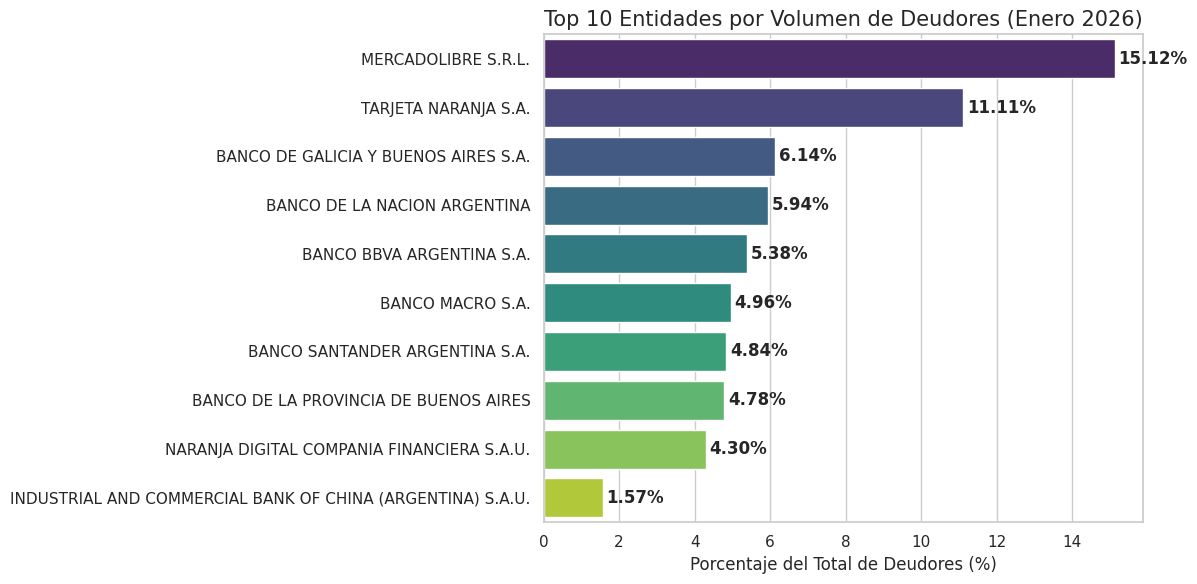

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparamos el Top 10 para graficar
top_10 = resumen.sort_values('porcentaje', ascending=False).head(10)

plt.figure(figsize=(12, 6))
# Ajuste para evitar FutureWarning: asignamos y a hue y desactivamos la leyenda
sns.barplot(data=top_10, x='porcentaje', y='denominacion', hue='denominacion', palette='viridis', legend=False)

plt.title('Top 10 Entidades por Volumen de Deudores (Enero 2026)', fontsize=15)
plt.xlabel('Porcentaje del Total de Deudores (%)')
plt.ylabel('')

# Añadimos etiquetas de valor a la derecha de cada barra
for i, p in enumerate(top_10['porcentaje']):
    plt.text(p + 0.1, i, f'{p:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Celda 4: Múltiple Correspondencias (MCA)

Iniciando Muestreo Estratificado optimizado (20%)...


/tmp/ipykernel_638/2369937502.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_mca_2026.groupby('estrato', group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))


Muestra estratificada: 7803451 registros.


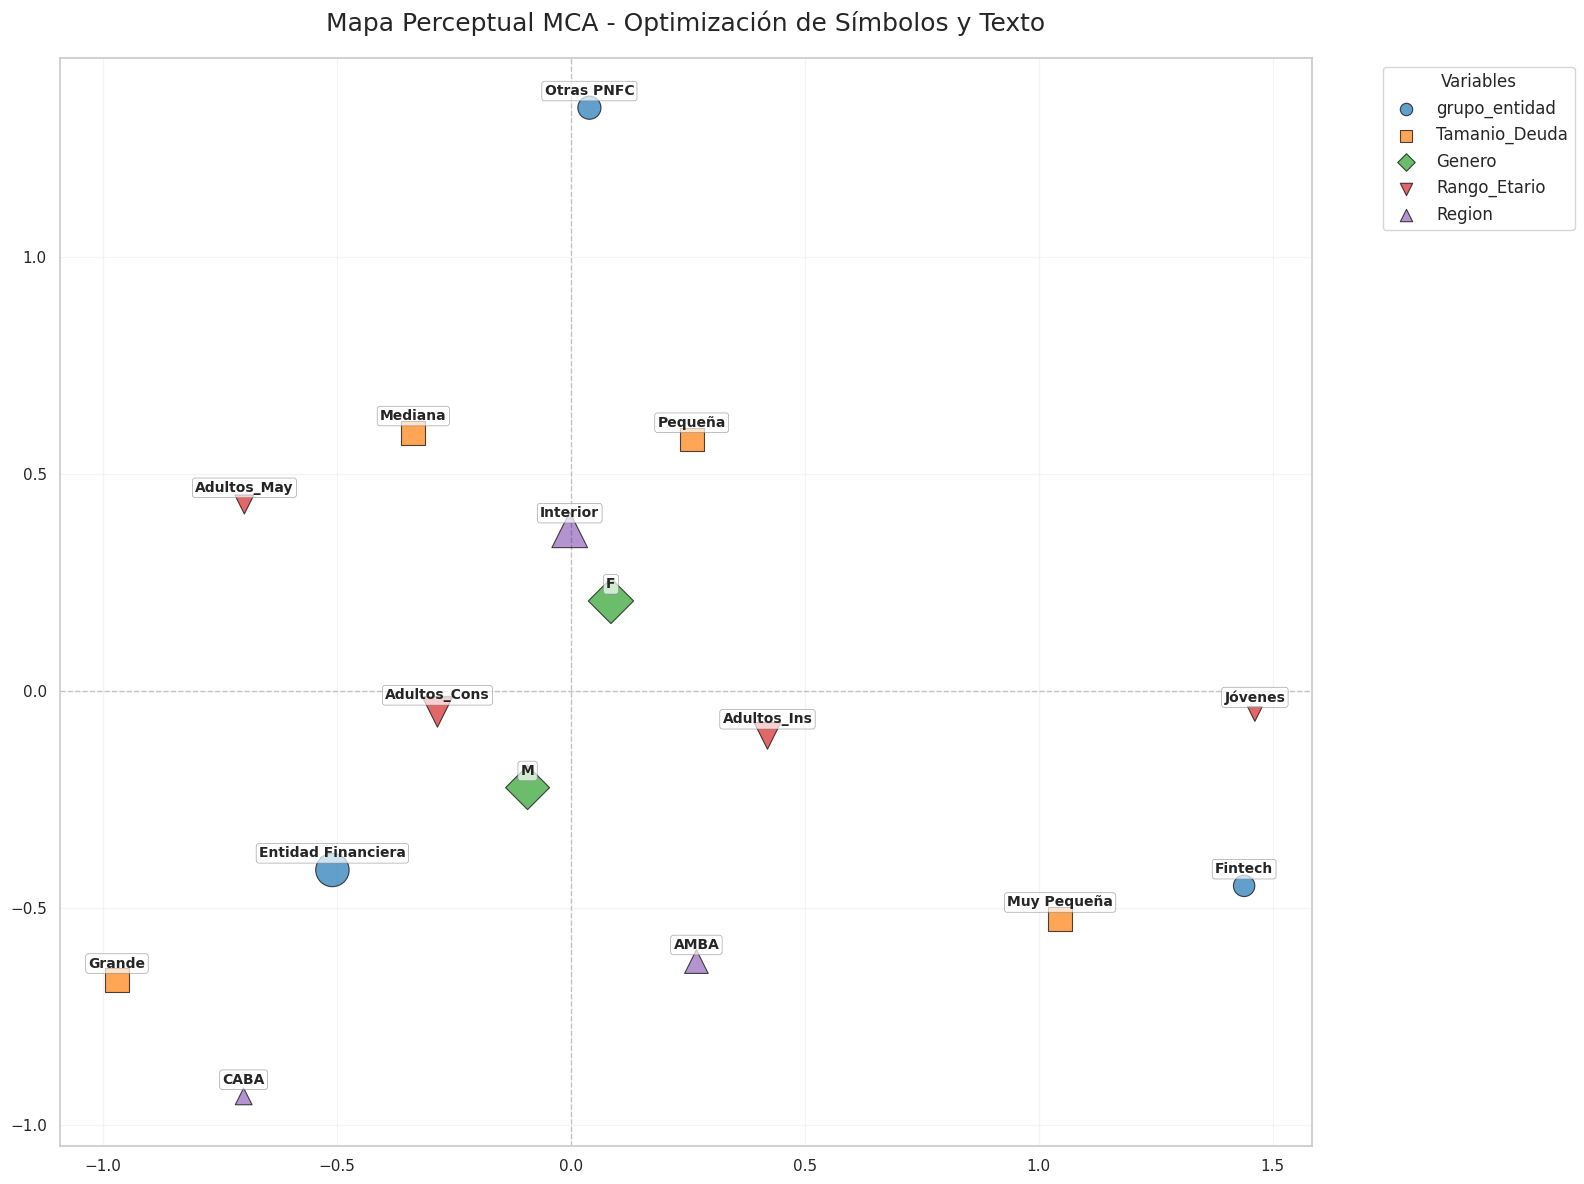

In [10]:
import prince
import matplotlib.pyplot as plt
import pandas as pd
import gc
import os

ruta_mca_final = '/content/drive/MyDrive/Tesis2026/df_mca_2026_final.parquet'

if 'df_mca_2026' not in locals():
    if os.path.exists(ruta_mca_final):
        df_mca_2026 = pd.read_parquet(ruta_mca_final)

if 'df_mca_2026' in locals():
    print("Iniciando Muestreo Estratificado optimizado (20%)...")

    # Estratificación por variables demográficas
    df_mca_2026['estrato'] = (df_mca_2026['Genero'].astype(str) + "_" +
                              df_mca_2026['Rango_Etario'].astype(str) + "_" +
                              df_mca_2026['Region'].astype(str))

    df_sample = df_mca_2026.groupby('estrato', group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))

    df_mca_2026.drop(columns=['estrato'], inplace=True)
    df_sample = df_sample.drop(columns=['estrato'])

    print(f"Muestra estratificada: {len(df_sample)} registros.")
    gc.collect()

    mca_26 = prince.MCA(n_components=2, n_iter=3, copy=False, engine='sklearn', random_state=42)
    mca_26 = mca_26.fit(df_sample)
    col_coords = mca_26.column_coordinates(df_sample)

    frecuencias_dict = {}
    for col in df_mca_2026.columns:
        val_counts = df_mca_2026[col].value_counts()
        for val, count in val_counts.items():
            frecuencias_dict[f"{col}__{val}"] = count

    palette = {'grupo_entidad': '#1f77b4', 'Tamanio_Deuda': '#ff7f0e', 'Genero': '#2ca02c', 'Rango_Etario': '#d62728', 'Region': '#9467bd'}
    markers = {'grupo_entidad': 'o', 'Tamanio_Deuda': 's', 'Genero': 'D', 'Rango_Etario': 'v', 'Region': '^'}

    plt.figure(figsize=(16, 12))

    for var_name in palette.keys():
        mask = [idx.startswith(f"{var_name}__") for idx in col_coords.index]
        subset = col_coords[mask]

        if not subset.empty:
            subset_counts = [frecuencias_dict.get(idx, 100) for idx in subset.index]
            max_total = max(frecuencias_dict.values())
            # REDUCCIÓN FINAL: Bajamos la escala a 600 y base a 60 para que el símbolo no explote
            subset_sizes = [(c / max_total * 600) + 60 for c in subset_counts]

            plt.scatter(subset[0], subset[1], s=subset_sizes, alpha=0.7,
                        color=palette[var_name], marker=markers[var_name],
                        label=var_name, edgecolors='black', linewidth=0.8)

            for idx in subset.index:
                label = idx.split('__')[-1]
                plt.annotate(label, (subset.loc[idx, 0], subset.loc[idx, 1]),
                             fontsize=10, fontweight='bold', ha='center', va='center',
                             xytext=(0, 12), textcoords='offset points', # Desplazamos el texto arriba
                             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='gray', lw=0.5))

    plt.axhline(0, color='black', lw=1, ls='--', alpha=0.2)
    plt.axvline(0, color='black', lw=1, ls='--', alpha=0.2)
    plt.title('Mapa Perceptual MCA - Optimización de Símbolos y Texto', fontsize=18, pad=20)

    lgnd = plt.legend(title="Variables", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    for handle in lgnd.legend_handles:
        handle.set_sizes([80.0]) # Símbolos de leyenda pequeños y uniformes

    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    del df_sample
    gc.collect()

In [11]:
import joblib

# Definir rutas de exportación
ruta_modelo = '/content/drive/MyDrive/Tesis2026/mca_model_2026.joblib'
ruta_coords = '/content/drive/MyDrive/Tesis2026/mca_coords_2026.parquet'

print("Exportando modelo MCA y coordenadas...")

# 1. Guardar el objeto del modelo (incluye autovalores y parámetros)
joblib.dump(mca_26, ruta_modelo)

# 2. Guardar las coordenadas de las columnas para recrear el gráfico rápidamente
col_coords.to_parquet(ruta_coords)

print(f"Modelo guardado en: {ruta_modelo}")
print(f"Coordenadas guardadas en: {ruta_coords}")

Exportando modelo MCA y coordenadas...
Modelo guardado en: /content/drive/MyDrive/Tesis2026/mca_model_2026.joblib
Coordenadas guardadas en: /content/drive/MyDrive/Tesis2026/mca_coords_2026.parquet


# Parte B - Analisis de trayectorias Enero 2025 - Enero 2026

## Data Loading - Enero 2025

In [1]:
import pandas as pd
import gc
import fastparquet

# 1. Cargar catálogo
ruta_entidades = '/content/drive/MyDrive/Tesis2026/EntidadesFinancierasBCRA.csv'
entidades = pd.read_csv(ruta_entidades)[['cod_entidad', 'grupo_entidad']]
entidades['cod_entidad'] = entidades['cod_entidad'].astype(str).str.zfill(5)

# 2. Cargar y procesar deudores (Enero 2025)
ruta_deudores_25 = '/content/drive/MyDrive/Tesis2026/deudores_enero_2025.parquet'
chunks_list = []

try:
    parquet_file = fastparquet.ParquetFile(ruta_deudores_25)
    for i, chunk in enumerate(parquet_file.iter_row_groups(columns=['cod_entidad', 'tipo_id', 'nro_id', 'prestamos'])):
        chunk = chunk[chunk['tipo_id'] == '11'].copy()
        if not chunk.empty:
            chunk = chunk.rename(columns={'nro_id': 'cuit', 'prestamos': 'deuda_total'})
            chunk['cuit'] = chunk['cuit'].astype(str)
            chunk['cod_entidad'] = chunk['cod_entidad'].astype(str).str.zfill(5)
            chunk = pd.merge(chunk, entidades, on='cod_entidad', how='left')
            chunks_list.append(chunk[['cuit', 'deuda_total', 'grupo_entidad']])
        if i % 100 == 0: gc.collect()

    df_2025 = pd.concat(chunks_list, ignore_index=True)

    # Clasificar y obtener cortes
    df_2025['Tamanio_Deuda'], bins = pd.qcut(df_2025['deuda_total'], q=4, labels=['Muy Pequeña', 'Pequeña', 'Mediana', 'Grande'], retbins=True)
    print(f"Cortes de Deuda 2025: {bins}")

    # Guardar archivo intermedio y limpiar
    ruta_intermedia_deuda = '/content/drive/MyDrive/Tesis2026/deudas_enero_2025_Categoricas.parquet'
    df_2025[['cuit', 'grupo_entidad', 'Tamanio_Deuda']].to_parquet(ruta_intermedia_deuda, index=False)
    print(f"Archivo de deudas 2025 guardado en: {ruta_intermedia_deuda}")

    del df_2025, chunks_list
    gc.collect()
except Exception as e:
    print(f"Error: {e}")

Cortes de Deuda 2025: [0.0000000e+00 1.2800000e+02 4.2100000e+02 1.2100000e+03 5.3007524e+08]
Archivo de deudas 2025 guardado en: /content/drive/MyDrive/Tesis2026/deudas_enero_2025_Categoricas.parquet


## Cruce de Enero 2025 con Padron 2026

In [2]:
!pip install polars
import polars as pl
import pandas as pd
import gc
import os

# Rutas para 2025
ruta_deuda_25 = '/content/drive/MyDrive/Tesis2026/deudas_enero_2025_Categoricas.parquet'
ruta_padron = '/content/drive/MyDrive/Tesis2026/padron_categorico_enero_2026.parquet'
ruta_mca_final_25 = '/content/drive/MyDrive/Tesis2026/df_mca_2025_final.parquet'

# Borrar si ya existe para empezar limpio
if os.path.exists(ruta_mca_final_25): os.remove(ruta_mca_final_25)

print("Iniciando Join ultra-eficiente para 2025 con Polars (Lazy Engine)...")

# Escaneamos los archivos
d_lazy = pl.scan_parquet(ruta_deuda_25)
p_lazy = pl.scan_parquet(ruta_padron)

for digito in range(10):
    print(f"Procesando fragmento CUIT termina en {digito}...      ", end='\r')

    filtro = pl.col('cuit').str.ends_with(str(digito))

    fragmento_join = (
        d_lazy.filter(filtro)
        .join(p_lazy.filter(filtro), on='cuit', how='inner')
        .drop('cuit')
        .drop_nulls()
        .collect()
    )

    if fragmento_join.height > 0:
        df_temp = fragmento_join.to_pandas()
        for col in df_temp.columns:
            df_temp[col] = df_temp[col].astype('category')

        if not os.path.exists(ruta_mca_final_25):
            df_temp.to_parquet(ruta_mca_final_25, engine='fastparquet', index=False)
        else:
            df_temp.to_parquet(ruta_mca_final_25, engine='fastparquet', append=True, index=False)

        del df_temp

    del fragmento_join
    gc.collect()

# Liberar punteros lazy antes de la carga final
del d_lazy, p_lazy
gc.collect()

print("\n¡Proceso 2025 finalizado! Cargando resultado final...")
df_mca_2025 = pd.read_parquet(ruta_mca_final_25)
print(f"Registros totales consolidados (2025): {len(df_mca_2025)}")
display(df_mca_2025.info())
display(df_mca_2025.head())


Iniciando Join ultra-eficiente para 2025 con Polars (Lazy Engine)...

¡Proceso 2025 finalizado! Cargando resultado final...
Registros totales consolidados (2025): 32973572
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32973572 entries, 0 to 32973571
Data columns (total 5 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   grupo_entidad  object
 1   Tamanio_Deuda  object
 2   Genero         object
 3   Rango_Etario   object
 4   Region         object
dtypes: object(5)
memory usage: 1.2+ GB


None

,grupo_entidad,Tamanio_Deuda,Genero,Rango_Etario,Region
0,Entidad Financiera,Mediana,F,Adultos_Cons,Interior
1,Otras PNFC,Muy Pequeña,F,Adultos_Cons,Interior
2,Otras PNFC,Muy Pequeña,F,Adultos_Cons,Interior
3,Entidad Financiera,Mediana,M,Adultos_May,Interior
4,Entidad Financiera,Muy Pequeña,F,Adultos_May,Interior


## MCA Individual para 2025

Cargando dataset 2025 desde Drive...
Iniciando Muestreo Estratificado (20%) para 2025 (32973572 registros)...


/tmp/ipykernel_19637/1901465133.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample_25 = df_mca_2025.groupby('estrato', group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))


Muestra estratificada 2025: 6594715 registros.


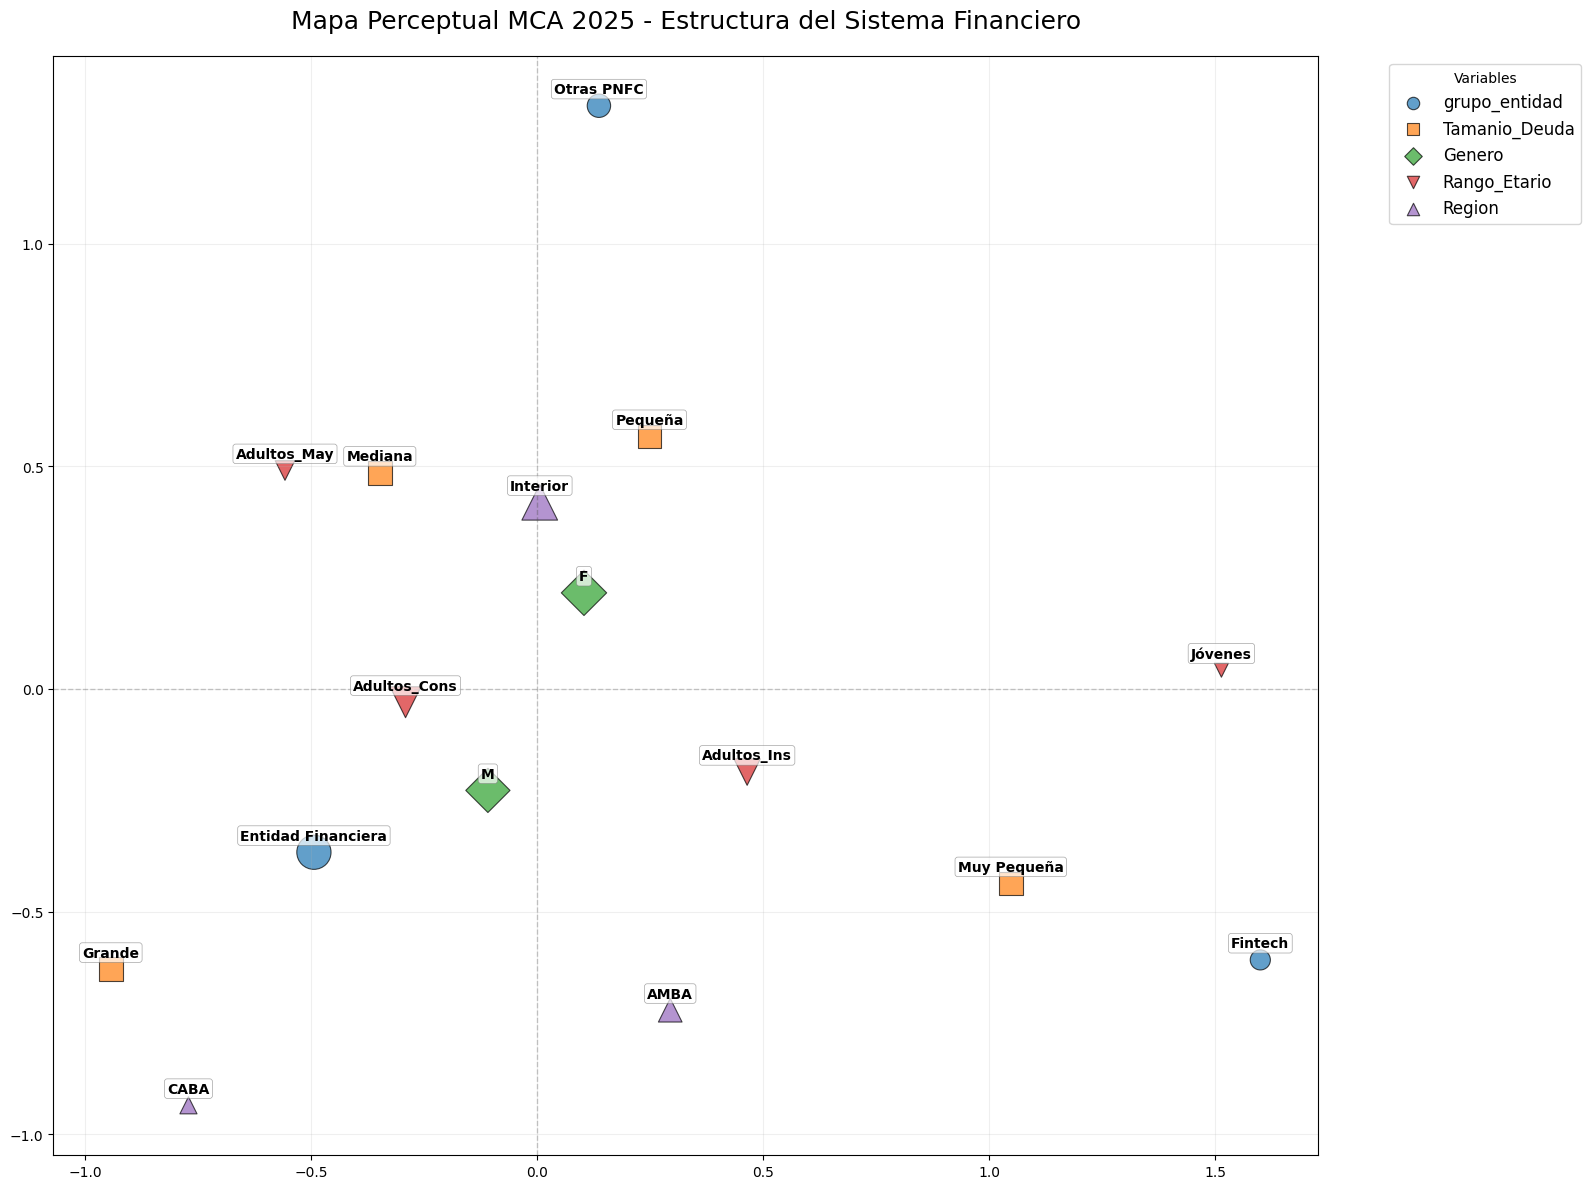

In [1]:
import prince
import matplotlib.pyplot as plt
import pandas as pd
import gc
import os

ruta_mca_final_25 = '/content/drive/MyDrive/Tesis2026/df_mca_2025_final.parquet'

# 1. Cargar el dataset si no está en memoria
if 'df_mca_2025' not in locals():
    if os.path.exists(ruta_mca_final_25):
        print("Cargando dataset 2025 desde Drive...")
        df_mca_2025 = pd.read_parquet(ruta_mca_final_25)

if 'df_mca_2025' in locals():
    print(f"Iniciando Muestreo Estratificado (20%) para 2025 ({len(df_mca_2025)} registros)...")

    # Estratificación por variables demográficas
    df_mca_2025['estrato'] = (df_mca_2025['Genero'].astype(str) + "_" +
                              df_mca_2025['Rango_Etario'].astype(str) + "_" +
                              df_mca_2025['Region'].astype(str))

    df_sample_25 = df_mca_2025.groupby('estrato', group_keys=False).apply(lambda x: x.sample(frac=0.2, random_state=42))

    df_mca_2025.drop(columns=['estrato'], inplace=True)
    df_sample_25 = df_sample_25.drop(columns=['estrato'])

    print(f"Muestra estratificada 2025: {len(df_sample_25)} registros.")
    gc.collect()

    # 2. Ejecución del MCA
    mca_25_ind = prince.MCA(n_components=2, n_iter=3, copy=False, engine='sklearn', random_state=42)
    mca_25_ind = mca_25_ind.fit(df_sample_25)
    col_coords = mca_25_ind.column_coordinates(df_sample_25)

    # 3. Cálculo de frecuencias para el tamaño de las burbujas
    frecuencias_dict = {}
    for col in df_mca_2025.columns:
        val_counts = df_mca_2025[col].value_counts()
        for val, count in val_counts.items():
            frecuencias_dict[f"{col}__{val}"] = count

    # 4. Visualización Personalizada
    palette = {'grupo_entidad': '#1f77b4', 'Tamanio_Deuda': '#ff7f0e', 'Genero': '#2ca02c', 'Rango_Etario': '#d62728', 'Region': '#9467bd'}
    markers = {'grupo_entidad': 'o', 'Tamanio_Deuda': 's', 'Genero': 'D', 'Rango_Etario': 'v', 'Region': '^'}

    plt.figure(figsize=(16, 12))

    for var_name in palette.keys():
        mask = [idx.startswith(f"{var_name}__") for idx in col_coords.index]
        subset = col_coords[mask]

        if not subset.empty:
            subset_counts = [frecuencias_dict.get(idx, 100) for idx in subset.index]
            max_total = max(frecuencias_dict.values())
            subset_sizes = [(c / max_total * 600) + 60 for c in subset_counts]

            plt.scatter(subset[0], subset[1], s=subset_sizes, alpha=0.7,
                        color=palette[var_name], marker=markers[var_name],
                        label=var_name, edgecolors='black', linewidth=0.8)

            for idx in subset.index:
                label = idx.split('__')[-1]
                plt.annotate(label, (subset.loc[idx, 0], subset.loc[idx, 1]),
                             fontsize=10, fontweight='bold', ha='center', va='center',
                             xytext=(0, 12), textcoords='offset points',
                             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='gray', lw=0.5))

    plt.axhline(0, color='black', lw=1, ls='--', alpha=0.2)
    plt.axvline(0, color='black', lw=1, ls='--', alpha=0.2)
    plt.title('Mapa Perceptual MCA 2025 - Estructura del Sistema Financiero', fontsize=18, pad=20)

    lgnd = plt.legend(title="Variables", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    for handle in lgnd.legend_handles:
        handle.set_sizes([80.0])

    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    del df_sample_25
    gc.collect()
else:
    print("Error: El dataframe 'df_mca_2025' no está disponible.")

# Concatenacion de MCA 2025 y MCA 2026

Armamos distintas etiquetas Fintech_2025 y Fintech_2026, Entidades Financieras_2025 y Entidades Financieras 2026 etc. Concatenamos el dataframe y lo llevamos a dos dimensiones para analizar trayectorias.

In [2]:
import polars as pl
import gc

ruta_2025 = '/content/drive/MyDrive/Tesis2026/df_mca_2025_final.parquet'
ruta_2026 = '/content/drive/MyDrive/Tesis2026/df_mca_2026_final.parquet'
ruta_consolidado_total = '/content/drive/MyDrive/Tesis2026/df_mca_trayectoria_completa.parquet'

print("Iniciando concatenación vía Streaming (Sink) para evitar corrupción de archivo...")

# 1. Definimos los planes lazy
lazy_25 = pl.scan_parquet(ruta_2025).with_columns([
    (pl.col('grupo_entidad').cast(pl.Utf8) + "_2025").alias('grupo_entidad_trayectoria')
])

lazy_26 = pl.scan_parquet(ruta_2026).with_columns([
    (pl.col('grupo_entidad').cast(pl.Utf8) + "_2026").alias('grupo_entidad_trayectoria')
])

# 2. Concatenamos y usamos sink_parquet para escribir directo a disco de forma segura
# Esto procesa los datos por fragmentos sin saturar la RAM
pl.concat([lazy_25, lazy_26]).sink_parquet(ruta_consolidado_total)

print(f"¡Archivo consolidado exitosamente en: {ruta_consolidado_total}!")

# 3. Verificamos integridad y tamaño
stats = pl.scan_parquet(ruta_consolidado_total).select(pl.len()).collect()
print(f"Registros totales validados: {stats.item()}")

del lazy_25, lazy_26
gc.collect()

Iniciando concatenación vía Streaming (Sink) para evitar corrupción de archivo...
¡Archivo consolidado exitosamente en: /content/drive/MyDrive/Tesis2026/df_mca_trayectoria_completa.parquet!
Registros totales validados: 71990819


60

## Analisis De Trayectorias

In [3]:
import polars as pl
import pandas as pd
import prince
import gc
import plotly.graph_objects as go

ruta_consolidado = '/content/drive/MyDrive/Tesis2026/df_mca_trayectoria_completa.parquet'

print("Iniciando muestreo robusto para MCA...")

# 1. En lugar de scan_parquet (lazy), leemos una fracción directamente
# Usamos pl.read_parquet con low_memory para obtener la muestra
try:
    # Leemos solo el 0.5% de los datos (aprox 350k filas) para asegurar que quepa en RAM
    df_sample_pl = pl.read_parquet(ruta_consolidado, use_pyarrow=True, low_memory=True)

    # Realizamos un segundo muestreo exacto para llegar al target
    target_size = 250000
    if len(df_sample_pl) > target_size:
        df_sample = df_sample_pl.sample(n=target_size, seed=42).to_pandas()
    else:
        df_sample = df_sample_pl.to_pandas()

    print(f"Muestra de {len(df_sample)} registros cargada exitosamente.")

    # Liberar Polars
    del df_sample_pl
    gc.collect()

    # 2. MCA
    print("Ejecutando MCA...")
    mca = prince.MCA(n_components=2, n_iter=3, random_state=42)
    # Eliminamos 'grupo_entidad' ya que usaremos 'grupo_entidad_trayectoria' para el mapa
    mca = mca.fit(df_sample.drop(columns=['grupo_entidad']))

    coords = mca.column_coordinates(df_sample.drop(columns=['grupo_entidad']))

    # 3. Graficar Trayectorias
    fig = go.Figure()

    # Separar coordenadas de trayectoria y contexto
    mask_tray = coords.index.str.contains('grupo_entidad_trayectoria')
    tray_coords = coords[mask_tray].copy()
    context_coords = coords[~mask_tray]

    # Añadir puntos de contexto
    fig.add_trace(go.Scatter(
        x=context_coords[0], y=context_coords[1],
        mode='markers+text',
        text=context_coords.index.str.split('__').str[-1],
        marker=dict(color='lightgrey', size=6, opacity=0.5),
        name='Demografía/Deuda'
    ))

    # Procesar Trayectorias
    tray_coords['label'] = tray_coords.index.str.split('__').str[-1]
    tray_coords['grupo'] = tray_coords['label'].str.rsplit('_', n=1).str[0]
    tray_coords['anio'] = tray_coords['label'].str.rsplit('_', n=1).str[-1]

    for grupo in tray_coords['grupo'].unique():
        sub = tray_coords[tray_coords['grupo'] == grupo]
        if len(sub) >= 2:
            p25 = sub[sub['anio'] == '2025']
            p26 = sub[sub['anio'] == '2026']

            if not p25.empty and not p26.empty:
                x0, y0 = p25[0].iloc[0], p25[1].iloc[0]
                x1, y1 = p26[0].iloc[0], p26[1].iloc[0]

                fig.add_trace(go.Scatter(
                    x=[x0, x1], y=[y0, y1],
                    mode='lines+markers+text',
                    name=grupo,
                    text=[f"{grupo} '25", f"{grupo} '26"],
                    textposition="top center"
                ))

                fig.add_annotation(
                    x=x1, y=y1, ax=x0, ay=y0,
                    xref="x", yref="y", axref="x", ayref="y",
                    showarrow=True, arrowhead=3, arrowsize=1, arrowwidth=2
                )

    fig.update_layout(
        title="Evolución del Sistema Financiero (2025-2026) - Espacio Factorial MCA",
        template="plotly_white",
        height=700
    )
    fig.show()

except Exception as e:
    print(f"Error en el proceso de visualización: {e}")

Leyendo y muestreando datos con Polars para proteger la RAM...
Muestra de 250000 registros cargada en Pandas.
Entrenando modelo MCA...
Coordenadas factoriales calculadas.


39

In [4]:
import plotly.graph_objects as go
import numpy as np

# 1. Extraer coordenadas específicas de Fintech
f25 = tray_coords[tray_coords.index.str.contains('Fintech_2025')]
f26 = tray_coords[tray_coords.index.str.contains('Fintech_2026')]

if not f25.empty and not f26.empty:
    x0, y0 = f25[0].iloc[0], f25[1].iloc[0]
    x1, y1 = f26[0].iloc[0], f26[1].iloc[0]

    # 2. Crear el gráfico de contribución
    fig = go.Figure()

    # Añadir todas las variables de contexto (fondo)
    fig.add_trace(go.Scatter(
        x=context_coords[0], y=context_coords[1],
        mode='markers+text',
        text=context_coords.index.str.split('__').str[-1],
        textposition="top center",
        marker=dict(color='rgba(150, 150, 150, 0.4)', size=8),
        name='Variables de Contexto'
    ))

    # Resaltar la trayectoria Fintech
    fig.add_trace(go.Scatter(
        x=[x0, x1], y=[y0, y1],
        mode='lines+markers+text',
        line=dict(color='firebrick', width=4),
        marker=dict(size=12, symbol='arrow-bar-up'),
        text=["Fintech 2025", "Fintech 2026"],
        textfont=dict(size=14, color="firebrick"),
        name='Trayectoria Fintech'
    ))

    # Dibujar la flecha de desplazamiento
    fig.add_annotation(
        x=x1, y=y1, ax=x0, ay=y0,
        xref="x", yref="y", axref="x", ayref="y",
        showarrow=True, arrowhead=3, arrowsize=1.5, arrowwidth=3, arrowcolor="firebrick"
    )

    # Calcular distancias para ver qué variables definen el perfil
    # (Proximidad de las variables a la posición final 2026)
    context_coords['dist_to_fintech_26'] = np.sqrt((context_coords[0] - x1)**2 + (context_coords[1] - y1)**2)
    top_influencers = context_coords.sort_values('dist_to_fintech_26').head(5)

    # Resaltar los principales descriptores del perfil Fintech 2026
    fig.add_trace(go.Scatter(
        x=top_influencers[0], y=top_influencers[1],
        mode='markers',
        marker=dict(color='gold', size=15, line=dict(width=2, color='black')),
        name='Descriptores Clave (Perfil 2026)'
    ))

    fig.update_layout(
        title="Análisis de Contribución: ¿Qué define el movimiento de las Fintech?",
        xaxis_title="Dimensión 1 (Bancarización/Edad)",
        yaxis_title="Dimensión 2 (Estabilidad/Región)",
        template="plotly_white",
        height=800,
        showlegend=True
    )

    fig.show()

    print(f"El desplazamiento neto fue de {np.sqrt((x1-x0)**2 + (y1-y0)**2):.4f} unidades factoriales.")
    print("\nVariables más cercanas al perfil Fintech 2026:")
    for idx in top_influencers.index:
        print(f"- {idx.replace('__', ': ')}")
else:
    print("Error: No se encontraron las coordenadas de Fintech en el modelo.")

/tmp/ipykernel_13536/3248553182.py:45: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



El desplazamiento neto fue de 0.1748 unidades factoriales.

Variables más cercanas al perfil Fintech 2026:
- Tamanio_Deuda: Muy Pequeña
- Rango_Etario: Jóvenes
- Rango_Etario: Adultos_Ins
- Region: AMBA
- Genero: F


In [5]:
import numpy as np
import pandas as pd

# 1. Obtener coordenadas de la variable de interés
coord_adulto_mayor = context_coords.loc['Rango_Etario__Adultos_May'][[0, 1]].values

# 2. Obtener coordenadas de Fintech para ambos años
coord_f25 = tray_coords[tray_coords.index.str.contains('Fintech_2025')][[0, 1]].values[0]
coord_f26 = tray_coords[tray_coords.index.str.contains('Fintech_2026')][[0, 1]].values[0]

# 3. Calcular distancias euclidianas
dist_25 = np.linalg.norm(coord_f25 - coord_adulto_mayor)
dist_26 = np.linalg.norm(coord_f26 - coord_adulto_mayor)

# 4. Calcular el desplazamiento total de Fintech y cuánto de ese vector apunta hacia Adultos Mayores
vector_fintech = coord_f26 - coord_f25
vector_hacia_objetivo = coord_adulto_mayor - coord_f25

# Proyección del movimiento sobre el vector hacia Adultos Mayores
# (Qué tanto del paso que dio Fintech fue en dirección a los Adultos Mayores)
proyeccion = np.dot(vector_fintech, vector_hacia_objetivo) / np.linalg.norm(vector_hacia_objetivo)
porcentaje_explicado = (proyeccion / np.linalg.norm(vector_fintech)) * 100

print(f"--- Análisis de Proximidad a Adultos Mayores ---")
print(f"Distancia en 2025: {dist_25:.4f}")
print(f"Distancia en 2026: {dist_26:.4f}")
print(f"Reducción de distancia: {dist_25 - dist_26:.4f}")
print(f"\nInterpretación: El {porcentaje_explicado:.2f}% del desplazamiento total de las Fintech ocurrió en dirección directa hacia el perfil de Adultos Mayores.")

--- Análisis de Proximidad a Adultos Mayores ---
Distancia en 2025: 2.4391
Distancia en 2026: 2.3108
Reducción de distancia: 0.1283

Interpretación: El 75.04% del desplazamiento total de las Fintech ocurrió en dirección directa hacia el perfil de Adultos Mayores.
